In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from plot_utils import window_tpr, window_fpr, window_fnr

color_palette = ['#C0D6CA',
                 '#78ACA8',
                 '#2D6B8F',
                 '#235796',
                 '#E7C4C0',
                 '#E3A39A',
                 '#CA6F6A',
                 '#7B3841',
                 '#D5BC67',
                 '#20425B',
                 '#E77A5B',
                 '#9C9DB2',
                ]

In [2]:
def get_rate(event, model_name, threshold, dataset_name, method=None, rate_type='tpr'):
    rate = []
    for trial in range(8):
        if model_name=='AutoNHITS_TREAT':
            path = f'/CHIL2025_results/results_nhitstreat_ka1ka2_ka3_1.7_1.9_1ConcMiddle/{dataset_name}_6/treat_models/trial_treat_{trial}/forecasts.csv'
        elif model_name=='autonbeatsxtreat_cts':
            path = f'/CHIL2025_results/results_nbeats_dlinear_tft/{dataset_name}_6/treat_models/trial_treat_{trial}/forecasts.csv'
        elif (model_name=='AutoTFT')&(method=='treat'):
            path = f'/CHIL2025_results/results_nbeats_dlinear_tft/{dataset_name}_6/treat_models/trial_treat_{trial}/forecasts.csv'

        df = pd.read_csv(f'/home/extra_scratch/wpotosna'+path)

        if rate_type == 'True Positive Rate':
            rate.append(window_tpr(df, event=event, model_name=model_name, threshold=threshold))
        elif rate_type =='False Negative Rate':
            rate.append(window_fnr(df, event=event, model_name=model_name, threshold=threshold))
        elif rate_type =='False Positive Rate':
            rate.append(window_fpr(df, event=event, model_name=model_name, threshold=threshold))

    return np.mean(rate)


In [7]:
rate_type = 'True Positive Rate' #'False Positive Rate'
dataset_name = 'ohiot1dm_exog' #'simglucose_exog'
event = 'hyperglycemia' #'hypoglycemia' 

if event=='hyperglycemia':
    thresholds = np.linspace(160, 180, 5)
elif event =='hypoglycemia':
    thresholds = np.linspace(70, 90, 5)


nhits_treat_threshold_tpr = {}
for threshold in thresholds:
    nhits_treat_threshold_tpr[threshold] = get_rate(event=event, 
                                             model_name='AutoNHITS_TREAT',
                                             threshold=threshold, 
                                             dataset_name=dataset_name,
                                             rate_type=rate_type,
                                            )

nbeats_treat_threshold_tpr = {}
for threshold in thresholds:
    nbeats_treat_threshold_tpr[threshold] = get_rate(event=event, 
                                             model_name='autonbeatsxtreat_cts', 
                                             threshold=threshold, 
                                             dataset_name=dataset_name,
                                             rate_type=rate_type,
                                            )

tft_treat_threshold_tpr = {}
for threshold in thresholds:
    tft_treat_threshold_tpr[threshold] = get_rate(event=event, 
                                             model_name='AutoTFT', 
                                             threshold=threshold, 
                                             dataset_name=dataset_name,
                                             method = 'treat',
                                             rate_type=rate_type,
                                            )


/tmp/ipykernel_2738735/1059202959.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


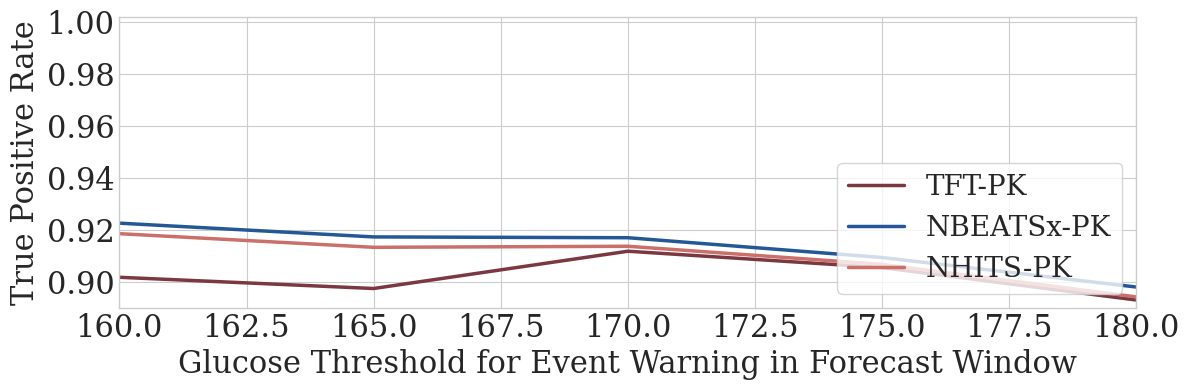

In [9]:
plt.style.use('seaborn-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.figure(figsize=(12, 4))
fontsize = 22

plt.plot(list(tft_treat_threshold_tpr.keys()), list(tft_treat_threshold_tpr.values()), linewidth=2.5, color=color_palette[7], label='TFT-PK')
plt.plot(list(nbeats_treat_threshold_tpr.keys()), list(nbeats_treat_threshold_tpr.values()), linewidth=2.5, color=color_palette[3], label='NBEATSx-PK')
plt.plot(list(nhits_treat_threshold_tpr.keys()), list(nhits_treat_threshold_tpr.values()), linewidth=2.5, color=color_palette[6], label='NHITS-PK')

# hyperglycemia figure parameters
plt.xlim([160, 180])
plt.ylim([0.89, 1.002]) # TPR
#plt.ylim([0.0001, 0.25]) # FPR

# hypoglycemia figure parameters
#plt.xlim([70, 90])
#plt.ylim([0.62, 1.005]) # TPR
#plt.ylim([0.0001, 0.40]) # FPR

#plt.legend(loc='upper left', frameon=True, fontsize=fontsize)
plt.legend(loc='lower right', frameon=True, fontsize=fontsize-2)

plt.xlabel('Glucose Threshold for Event Warning in Forecast Window', fontsize=fontsize)
plt.ylabel(rate_type, fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
#.yaxis.set_major_locator(ticker.LinearLocator(numticks=3))  # Exactly 6 ticks
plt.tight_layout()

#plt.savefig(f'/home/extra_scratch/wpotosna/{event}_{rate_type}_{dataset_name.split('_')[0]}.pdf')
